In [15]:
from w3_profiling import profiling
from main import w1_main, w2_main, w3_main, benchmark_all, benchmark_dtype, benchmark_numba_imp
import math

## Specs

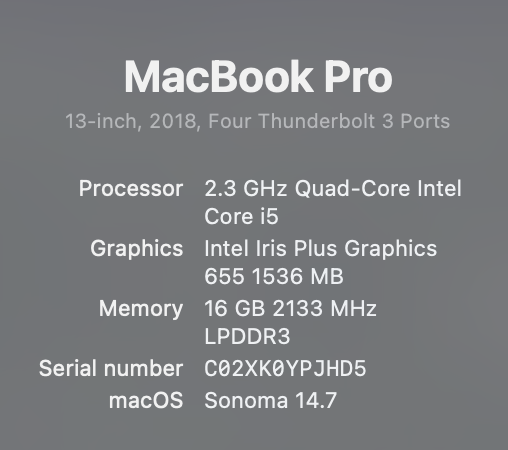

In [16]:
import numpy
import sys 
print(sys.version)
print('Numpy version:', numpy.__version__)

3.14.3 | packaged by conda-forge | (main, Feb  5 2026, 05:57:55) [Clang 20.1.8 ]
Numpy version: 2.3.5


## Measurement methodology
- 3 trials (4 if jit is involved as a warmup), take the median and report standard deviation.

## Comparison of Naive python, Numpy and Jit implementations

In [17]:
w1, w2, w03, w3, v1, v2, v1_5, v3 = benchmark_all(n_runs=4)

Week 1: Naive python implementatio 
Execution took: 7.423940 seconds
Execution took: 7.541094 seconds
Execution took: 7.042610 seconds
Execution took: 6.784738 seconds
Median execution time over 4 runs: 7.235365 seconds
Week 2: numpy vectorization
Execution took: 1.044154 seconds
Execution took: 1.079458 seconds
Execution took: 1.088902 seconds
Execution took: 1.094026 seconds
Median execution time over 4 runs: 1.105030 seconds
Week 3: Naive numba
Execution took: 0.638395 seconds
Execution took: 0.639059 seconds
Execution took: 0.665324 seconds
Execution took: 0.629507 seconds
Median execution time over 4 runs: 0.639604 seconds
Weel 3: optimized numba
Execution took: 0.087677 seconds
Execution took: 0.083868 seconds
Execution took: 0.086514 seconds
Execution took: 0.080716 seconds
Median execution time over 4 runs: 0.096136 seconds


In [10]:
print(f'std for naive = {math.sqrt(v1)}')
print(f'std for numpy = {math.sqrt(v2)}')
print(f'std for jit = {math.sqrt(v3)}')

std for naive = 0.44098152755249476
std for numpy = 0.06231675542648918
std for jit = 0.002996293307452575


As we can see, numpy is around 7 times faster than the naive approach, but after initialisation numba is about 8 times faster than that.

In [18]:
w3_median, w3_var, hyb_median, hyb_var, par_median, par_var = benchmark_numba_imp(n_runs=4) # Use first run as a warmup

full jit approach
Execution took: 0.089361 seconds
Execution took: 0.081932 seconds
Execution took: 0.081240 seconds
Execution took: 0.081869 seconds
Median execution time over 4 runs: 0.092687 seconds
Python loops approach
Execution took: 0.600831 seconds
Execution took: 0.570905 seconds
Execution took: 0.568214 seconds
Execution took: 0.565059 seconds
Median execution time over 4 runs: 0.569739 seconds
Parallel numba
Execution took: 0.028969 seconds
Execution took: 0.024749 seconds
Execution took: 0.024953 seconds
Execution took: 0.025345 seconds
Median execution time over 4 runs: 0.035161 seconds


In [19]:
print(f'numba all std: {math.sqrt(w3_var)}')
print(f'Numba with python loops std: {math.sqrt(hyb_var)}')
print(f'numba parallel: {math.sqrt(par_var)}')

numba all std: 0.005524966625723953
Numba with python loops std: 0.014906129403074727
numba parallel: 0.0024820781041116867


As we can see the approach of using jit for the loops gives a ~6x speedup and is comparable to numpy. 
As for parallel there's a ~3x increase

## Profiling

In [13]:
profiling('w1_main(1024)', 'w1')


Execution took: 1.001659 seconds
Mon Mar  2 09:41:56 2026    w1.prof

         1753108 function calls in 1.011 seconds

   Ordered by: cumulative time
   List reduced from 97 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    0.991    0.991 {built-in method builtins.exec}
        1    0.097    0.097    0.991    0.991 <string>:1(<module>)
        1    0.000    0.000    0.894    0.894 /Users/astatham/Documents/Development/NumericalComputingCourse/main.py:17(wrapper)
        1    0.000    0.000    0.894    0.894 /Users/astatham/Documents/Development/NumericalComputingCourse/main.py:38(w1_main)
        1    0.651    0.651    0.894    0.894 /Users/astatham/Documents/Development/NumericalComputingCourse/main.py:52(w1_f)
  1742918    0.246    0.000    0.246    0.000 {built-in method builtins.abs}
        2    0.005    0.003    0.009    0.005 {method '__exit__' of 'sqlite3.Connection' objects}
    10003    0.008

In [14]:
profiling('w2_main(1024)', 'w2')

Execution took: 0.235852 seconds
Mon Mar  2 09:41:57 2026    w2.prof

         684 function calls (678 primitive calls) in 0.240 seconds

   Ordered by: cumulative time
   List reduced from 182 to 10 due to restriction <10>

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000    0.236    0.236 {built-in method builtins.exec}
        1    0.000    0.000    0.236    0.236 <string>:1(<module>)
        1    0.000    0.000    0.130    0.130 /Users/astatham/Documents/Development/NumericalComputingCourse/main.py:83(w2_main)
        1    0.000    0.000    0.130    0.130 /Users/astatham/Documents/Development/NumericalComputingCourse/main.py:17(wrapper)
        1    0.130    0.130    0.130    0.130 /Users/astatham/Documents/Development/NumericalComputingCourse/main.py:96(f)
        2    0.106    0.053    0.106    0.053 {method 'control' of 'select.kqueue' objects}
        1    0.000    0.000    0.001    0.001 /Users/astatham/miniforge3/envs/conda_v

## Week 1 line profiler

Line No.      Hits         Time  Per Hit   % Time  Line Contents

==============================================================

    37                                           @timing
    38                                           @profile
    39                                           def w1_main(max_iters: int = 100, 
    40                                                   x_set: tuple = (-2.0, 1.0),    # Changed to tuple + floats
    41                                                   y_set: tuple = (-1.5, 1.5),    # Changed to tuple + floats
    42                                                   win_size: int = 100) -> np.ndarray :
    43                                               """Generate and plot the Mandelbrot set.
    44                                               Args: 
    45                                                   max_iter (int): Maximum number of iterations.
    46                                                   x_set (tuple): X-axis range.
    47                                                   y_set (tuple): Y-axis range.
    48                                                   win_size (int): Number of points in each axis.
    49                                               Returns:
    50                                                   np.ndarray: Mandelbrot set values in a 2D array.
    51                                               """
    52         1          4.0      4.0      0.0      def w1_f(points: np.ndarray[complex], mandelbrot_Set: np.ndarray[int], max_iters: int = 100) -> np.ndarray:
    53                                                       for i, c in enumerate(points):
    54                                                           z = 0
    55                                                           for j in range(max_iters):
    56                                                               z = z**2 + c
    57                                                               # Break if |Z| > 2
    58                                                               if abs(z) > 2:
    59                                                                   mandelbrot_set[i] = j
    60                                                                   break
    61                                                           else:
    62                                                               mandelbrot_set[i] = max_iters
    63                                                       return mandelbrot_set
    64                                           
    65                                           
    66         1          2.0      2.0      0.0      x_set, y_set = [-2, 1], [-1.5, 1.5]
    67         1        182.0    182.0      0.0      width = np.linspace(x_set[0], x_set[1], win_size)
    68         1         50.0     50.0      0.0      height = np.linspace(y_set[0], y_set[1], win_size)
    69         1          0.0      0.0      0.0      points = []
    70      1025        552.0      0.5      0.0      for w in width:
    71   1049600     487661.0      0.5      1.7          for h in height:
    72   1048576    2475414.0      2.4      8.5              points.append(w + h*1j)
    73         1      70138.0  70138.0      0.2      points = np.array(points)
    74                                           
    75                                               # Based on the 100x100 points, compute the mandelbrot set
    76         1        284.0    284.0      0.0      mandelbrot_set = np.zeros(points.shape, dtype=int)
    77                                               # Get n and c
    78         1   26051135.0 2.61e+07     89.6      mandelbrot_set = w1_f(points, mandelbrot_set, max_iters)
    79                                               # Reshape to 2D and plot        
    80         1         46.0     46.0      0.0      mandelbrot_set = np.reshape(mandelbrot_set, (len(width), len(height))).T
    81         1          1.0      1.0      0.0      return mandelbrot_set

## Numpy line profile
```
Function: w2_main at line 82

Line No      Hits         Time  Per Hit   % Time  Line Contents

==============================================================

    82                                           @profile
    83                                           def w2_main(max_iters: int = 100, 
    84                                                   x_set: tuple = (-2.0, 1.0),    # Changed to tuple + floats
    85                                                   y_set: tuple = (-1.5, 1.5),    # Changed to tuple + floats
    86                                                   win_size: int = 100) -> np.ndarray :
    87                                               """Generate and plot the Mandelbrot set.
    88                                               Args: 
    89                                                   max_iter (int): Maximum number of iterations.
    90                                                   x_set (tuple): X-axis range.
    91                                                   y_set (tuple): Y-axis range.
    92                                                   win_size (int): Number of points in each axis.
    93                                               Returns:
    94                                                   np.ndarray: Mandelbrot set values in a 2D array.
    95                                               """
    96         2         28.0     14.0      0.0      @timing
    97         2          2.0      1.0      0.0      def f(C: np.ndarray[complex], Z: np.ndarray, M: np.ndarray, max_iters: int) -> np.ndarray:
    98                                                   for _ in range(max_iters):
    99                                                       # Calculate the mask for every point in Z
   100                                                       mask = np.abs(Z) <= 2
   101                                                       # Calculate the new Z values 
   102                                                       Z[mask] = Z[mask]**2 + C[mask]
   103                                                       # Update M for points that are still within the escape radius
   104                                                       M[mask] += 1
   105                                                   return M
   106                                           
   107         1        139.0    139.0      0.0      width = np.linspace(x_set[0], x_set[1], win_size)
   108         1         44.0     44.0      0.0      height = np.linspace(y_set[0], y_set[1], win_size)
   109         1       8743.0   8743.0      0.7      X, Y = np.meshgrid(width, height)
   110         1      25774.0  25774.0      2.0      C = X + 1j * Y
   111                                               
   112                                               # Based on the 100x100 points, compute the mandelbrot set
   113         1       1479.0   1479.0      0.1      mandelbrot_set = np.zeros(C.shape, dtype=C.dtype)
   114                                           
   115                                               # Initialize Z and M arrays
   116         1       7463.0   7463.0      0.6      Z = np.zeros_like(C, dtype=complex)
   117         1       3458.0   3458.0      0.3      M = np.zeros_like(C, dtype=int) 
   118                                               # Compute the Mandelbrot set using the function f 
   119         1    1265805.0 1.27e+06     96.4      mandelbrot_set = f(C, Z, M, max_iters)
   120         1          1.0      1.0      0.0      return mandelbrot_set
   ```

## Numba 

```
Line No      Hits         Time  Per Hit   % Time  Line Contents

==============================================================
   214                                           @profile
   215                                           def w3_main(max_iters: int = 100, 
   216                                                   x_set: tuple = (-2.0, 1.0),    # Changed to tuple + floats
   217                                                   y_set: tuple = (-1.5, 1.5),    # Changed to tuple + floats
   218                                                   win_size: int = 100,
   219                                                   dtype: np.dtype = np.float64) -> np.ndarray :
   220                                               """Generate and plot the Mandelbrot set.
   221                                               Args: 
   222                                                   max_iter (int): Maximum number of iterations.
   223                                                   x_set (tuple): X-axis range.
   224                                                   y_set (tuple): Y-axis range.
   225                                                   win_size (int): Number of points in each axis.
   226                                               Returns:
   227                                                   np.ndarray: Mandelbrot set values in a 2D array.
   228                                               """
   229         1        155.0    155.0      0.0      width = np.linspace(x_set[0], x_set[1], win_size)
   230         1         43.0     43.0      0.0      height = np.linspace(y_set[0], y_set[1], win_size)
   231         1       8509.0   8509.0      0.4      X, Y = np.meshgrid(width, height)
   232         1      21823.0  21823.0      0.9      C = X + 1j * Y
   233                                               
   234                                               # Based on the 100x100 points, compute the mandelbrot set
   235         1         27.0     27.0      0.0      mandelbrot_set = np.zeros(C.shape, dtype=np.int32)
   236                                               # Compute the Mandelbrot set using the function f 
   237         1    2275248.0 2.28e+06     98.7      mandelbrot_set = w3_f(C, mandelbrot_set, max_iters)
   238         1          1.0      1.0      0.0      return mandelbrot_set
   ```


We can see that abs is called many times in the naive implementation, taking up a large amount of time, this is not the case in numpy

## float type comparison (64/32)

In [2]:
m_64, r_64, m_32, r_32, v64, v32 = benchmark_dtype(4)

Execution took: 0.772366 seconds
Execution took: 0.087485 seconds
Execution took: 0.085368 seconds
Execution took: 0.092202 seconds
Median execution time over 4 runs: 0.100624 seconds
Execution took: 0.256220 seconds
Execution took: 0.089414 seconds
Execution took: 0.086419 seconds
Execution took: 0.086312 seconds
Median execution time over 4 runs: 0.093267 seconds


In [5]:
print(f'std for float64: {math.sqrt(v64)}')
print(f'std for float32: {math.sqrt(v32)}')

std for float64: 0.30927014615179355
std for float32: 0.0740035387642772


We see no considerable speedup between float64 (top) and float32 (bottom)

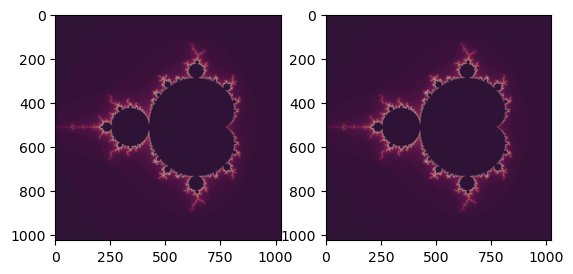

In [15]:
from matplotlib import pyplot as plt
plt.subplot(1,2,1)
plt.imshow(r_64, cmap='twilight_shifted_r')
plt.subplot(1,2,2)
plt.imshow(r_32, cmap='twilight_shifted_r')
plt.show()

## Takeaways
1. Very clean python code, not many comments to help understand the implementation occasionally
2. Profiling showed different numbers on the same parameters, in the same factor but still different
3. Better docstrings and Latex handin
4. Continue with better docstring

## Testing with chunksize with dask
Initially just test chunk sizes 8 - 1024 whilst doubling

In [31]:
from main import w6_testing
import pandas as pd
chunks = [8, 16, 32, 64, 128, 256, 512, 1024]
chunks, t_serial = w6_testing(win_size=4096, n_runs=5, testing_chunks=chunks)
df = pd.DataFrame(chunks)
df_transposed = df.transpose()
df_transposed = df_transposed.reset_index()
df_transposed.columns = ['No. Chunks','time', 'LIF']  # Rename the columns
df_transposed

df_transposed['vs x1'] = 8 / df_transposed['No. Chunks']  # Divide by 8
df_transposed['speedup'] = t_serial / df_transposed['time']   # Replace t_serial with your actual serial time
df_transposed

Dashboard: http://127.0.0.1:8787/status
Execution for serial took: 4.996563 seconds
median time for dask worker: 0.5843842570029665
median time for dask worker: 0.3501950099962414
median time for dask worker: 0.23746424399723765
median time for dask worker: 0.30570258099760395
median time for dask worker: 0.32461150999733945
median time for dask worker: 0.608089284003654
median time for dask worker: 0.9817927120020613
median time for dask worker: 1.8223486999995657


,No. Chunks,time,LIF,vs x1,speedup
0,8,0.584384,-0.064342,1.000000,8.550133
1,16,0.350195,-0.439303,0.500000,14.267944
2,32,0.237464,-0.619796,0.250000,21.041327
3,64,0.305703,-0.510539,0.125000,16.344523
4,128,0.324612,-0.480264,0.062500,15.392439
5,256,0.608089,-0.026388,0.031250,8.216824
6,512,0.981793,0.571949,0.015625,5.089224
7,1024,1.822349,1.917764,0.007812,2.741826


Seems like 16-64 has the best range, do a smaller sweep

In [ ]:
import numpy as np
chunks = np.linspace(16, 64, 8)
chunks, t_serial = w6_testing(win_size=4096, n_runs=5, testing_chunks=list(chunks))
df = pd.DataFrame(chunks)
df_transposed = df.transpose()
df_transposed = df_transposed.reset_index()
df_transposed.columns = ['No. Chunks','time', 'LIF']  # Rename the columns
df_transposed

df_transposed['vs x1'] = 8 / df_transposed['No. Chunks']  # Divide by 8
df_transposed['speedup'] = t_serial / df_transposed['time']   # Replace t_serial with your actual serial time
df_transposed

/Users/astatham/miniforge3/envs/conda_venv/lib/python3.14/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 49827 instead
  warnings.warn(


Dashboard: http://127.0.0.1:49827/status
Execution for serial took: 3.784015 seconds


2026-03-19 15:10:51,056 - distributed.worker - ERROR - Compute Failed
Key:       compute_mandelbrot_chunk-c7b3fbe6-7289-4d29-8d6b-4fe15b5392be
State:     executing
Task:  <Task 'compute_mandelbrot_chunk-c7b3fbe6-7289-4d29-8d6b-4fe15b5392be' compute_mandelbrot_chunk(...)>
Exception: 'TypingError(\'Failed in nopython mode pipeline (step: nopython frontend)\\n\\x1b\\x1b\\x1b\\x1bNo implementation of function Function(<built-in function empty>) found for signature:\\n \\n >>> empty(Tuple(float64, int64), dtype=class(int32))\\n \\nThere are 2 candidate implementations:\\n\\x1b - Of which 2 did not match due to:\\n Overload in function \\\'ol_np_empty\\\': File: numba/np/arrayobj.py: Line 4455.\\n   With argument(s): \\\'(Tuple(float64, int64), dtype=class(int32))\\\':\\x1b\\n\\x1b  Rejected as the implementation raised a specific error:\\n    TypingError: \\x1bCannot parse input types to function np.empty(Tuple(float64, int64), class(int32))\\x1b\\x1b\\n  raised from /Users/astatham/minifor

TypingError: Failed in nopython mode pipeline (step: nopython frontend)
[1m[1m[1m[1mNo implementation of function Function(<built-in function empty>) found for signature:
 
 >>> empty(Tuple(float64, int64), dtype=class(int32))
 
There are 2 candidate implementations:
[1m - Of which 2 did not match due to:
 Overload in function 'ol_np_empty': File: numba/np/arrayobj.py: Line 4455.
   With argument(s): '(Tuple(float64, int64), dtype=class(int32))':[0m
[1m  Rejected as the implementation raised a specific error:
    TypingError: [1mCannot parse input types to function np.empty(Tuple(float64, int64), class(int32))[0m[0m
  raised from /Users/astatham/miniforge3/envs/conda_venv/lib/python3.14/site-packages/numba/np/arrayobj.py:4474
[0m
[0m[1mDuring: resolving callee type: Function(<built-in function empty>)[0m
[0m[1mDuring: typing of call at /Users/astatham/Documents/Development/NumericalComputingCourse/multiprocessing_helpers.py (130)[0m
[1m
File "multiprocessing_helpers.p

function np.empty(Tuple(float64, int64), class(int32))\\x1b\\x1b\\n  raised from /Users/astatham/miniforge3/envs/conda_venv/lib/python3.14/site-packages/numba/np/arrayobj.py:4474\\n\\x1b\\n\\x1b\\x1bDuring: resolving callee type: Function(<built-in function empty>)\\x1b\\n\\x1b\\x1bDuring: typing of call at /Users/astatham/Documents/Development/NumericalComputingCourse/multiprocessing_helpers.py (130)\\x1b\\n\\x1b\\nFile "multiprocessing_helpers.py", line 130:\\x1b\\n\\x1bdef compute_mandelbrot_chunk(start_row, end_row, num_points,\\n    <source elided>\\n    """\\n\\x1b    result = np.empty((end_row - start_row, num_points), dtype=np.int32)\\n\\x1b    \\x1b^\\x1b\\x1b\\n\\n\\x1b\\x1bDuring: Pass nopython_type_inference\\x1b\')'
Traceback: '  File "/Users/astatham/miniforge3/envs/conda_venv/lib/python3.14/site-packages/numba/core/dispatcher.py", line 424, in _compile_for_args\n    error_rewrite(e, \'typing\')\n    ~~~~~~~~~~~~~^^^^^^^^^^^^^\n  File "/Users/astatham/miniforge3/envs/cond